In [18]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [19]:
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [20]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [21]:
df.shape

(244, 7)

In [22]:
X = df[['total_bill']]
y = df['tip']

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
model  = LinearRegression()

In [26]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
print("slope", model.coef_[0])
print("intercept", model.intercept_)

slope 0.1069637068526866
intercept 0.925235558557056


In [28]:
y_pred = model.predict(X_test)
y_pred

array([3.04525623, 1.86330727, 3.55119456, 3.69452593, 2.31576375,
       2.83881627, 3.96728338, 2.26014262, 2.50615915, 2.57033737,
       2.88160176, 2.07723468, 2.06439904, 2.47407003, 2.00236009,
       2.91903905, 2.92652651, 3.23351235, 2.68478854, 5.33107064,
       3.13831465, 3.13403611, 2.4558862 , 1.94673896, 3.16077703,
       2.17564129, 2.02375283, 3.62927807, 2.68906708, 6.07767732,
       4.99734388, 1.75313465, 2.83025918, 3.09552917, 2.74040966,
       3.50092162, 2.21200895, 5.53644096, 2.33287794, 3.35010279,
       2.04942412, 2.47834858, 3.48701634, 2.03017065, 2.03124029,
       1.25361414, 2.05798121, 2.92438724, 1.73388118])

In [29]:
results = {
    "actual": y_test.values,
    "predicted": y_pred,
}
results_df = pd.DataFrame(results)
results_df.head()

,actual,predicted
0,3.18,3.045256
1,2.00,1.863307
2,2.00,3.551195
3,5.16,3.694526
4,2.00,2.315764


In [30]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.5688142529229538


In [31]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.6208580000398984


In [32]:
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.5449381659234664


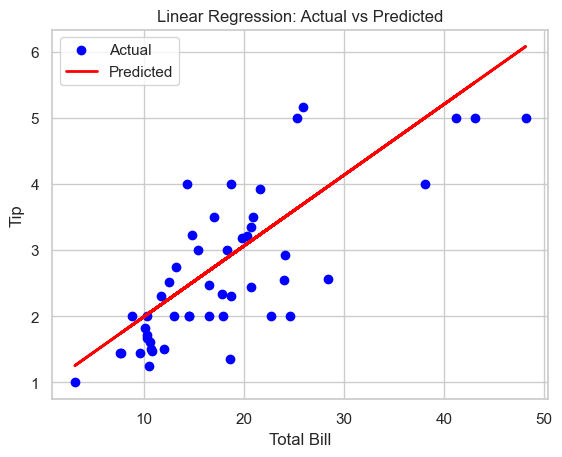

In [33]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.title('Linear Regression: Actual vs Predicted') 
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.show()

In [34]:
new_bill=[[50.0]]
prediction = model.predict(new_bill)
print(f"Predicted tip for a total bill of ${new_bill[0][0]}: ${prediction[0]:.2f}")

Predicted tip for a total bill of $50.0: $6.27
